#**스마트폰 센서 데이터 기반 모션 분류**

## 1.설정

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

In [ ]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

#### 1) 데이터로딩

In [ ]:
data01_train = pd.read_csv('data01_train.csv')
data01_test = pd.read_csv('data01_test.csv')
feature_list = pd.read_csv('features.csv')

In [ ]:
# 불필요한 데이터 삭제
data01_train.drop('subject', axis = 1, inplace = True)
data01_test.drop('subject', axis = 1, inplace = True)

#### 2) 기본 정보 조회

In [ ]:
# 전체 데이터의 상위 5개 행 확인
data01_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [ ]:
data01_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.509523,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.210792,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.579587,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.566291,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.447577,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,STANDING


In [ ]:
# 전체 데이터의 수치형 변수 분포 확인
numeric_cols = data01_train.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyBodyGyroJerkMag-skewness()',
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)'],
      dtype='object', length=561)


In [ ]:
data01_train[numeric_cols].describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [ ]:
data01_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


## 2.데이터 전처리

### (1) 1단계 모델링을 위한 레이블

In [ ]:
pwd

'/content/drive/MyDrive/AI/aivle/미프_2차'

In [ ]:
#Lable 추가(1단계 모델:정적(0), 동적(1) 행동 분류 모델 생성 )

activity_mapping = {
    'STANDING': 0,
    'SITTING': 0,
    'LAYING': 0,
    'WALKING': 1,
    'WALKING_UPSTAIRS': 1,
    'WALKING_DOWNSTAIRS': 1
}

data01_train['is_dynamic'] = data01_train['Activity'].map(activity_mapping)

# 확인
print(data01_train['is_dynamic'].value_counts())
print(data01_train[['Activity', 'is_dynamic']].head(10))

is_dynamic
0    3234
1    2647
Name: count, dtype: int64
             Activity  is_dynamic
0            STANDING           0
1              LAYING           0
2            STANDING           0
3             WALKING           1
4  WALKING_DOWNSTAIRS           1
5    WALKING_UPSTAIRS           1
6             WALKING           1
7            STANDING           0
8            STANDING           0
9            STANDING           0


### (2) x, y 분리

In [ ]:
#x,y 분리하기
select_features = ['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
                   'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
                   'tGravityAcc-max()-X', 'angle(X,gravityMean)', 'tBodyAcc-max()-X',
                   'tGravityAcc-max()-Y', 'angle(Y,gravityMean)',
                   'tGravityAcc-mean()-X']

x = data01_train[select_features]
y_act = data01_train['Activity']
y_dyna = data01_train['is_dynamic']

### (3) 데이터 분할
* train, val 분할

In [1]:
#데이터 분할
x_train, x_test, y_train, y_test = train_test_split(x, y_dyna, test_size = 0.2)

NameError: name 'train_test_split' is not defined

### (4) 스케일링


In [ ]:
#스케일링
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)

## **3.단계별 모델링**

### (1) 단계1

정적 행동(Laying, Sitting, Standing)과 동적 행동(동적 : Walking, Walking-Up, Walking-Down)을 구분하는 모델 생성

#### 1) 모델1

In [ ]:
#RandomForestClassifier로 모델링 진행
clear_session()

nfeatures = x.shape[1]

dyna_model = Sequential([
    Input(shape = (nfeatures, )),
    Dense(1, activation = 'sigmoid')
])

dyna_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 컴파일 및 학습
dyna_model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'binary_crossentropy')
dyna_hist = dyna_model.fit(x_train, y_train.values, epochs = 30, validation_split = 0.2).history

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5609 - val_loss: 0.3947
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3898 - val_loss: 0.3102
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3116 - val_loss: 0.2570
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2647 - val_loss: 0.2191
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2260 - val_loss: 0.1904
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1987 - val_loss: 0.1683
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1709 - val_loss: 0.1505
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1589 - val_loss: 0.1357
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1391 - val_loss: 0.1230
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1308 - val_loss: 0.1126
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1200 - val_loss: 0.1027
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

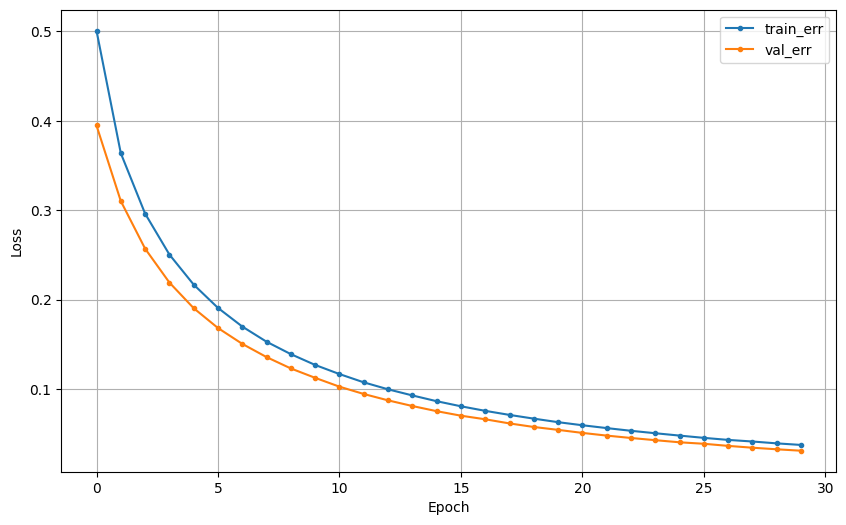

In [ ]:
# 학습곡선
dl_history_plot(dyna_hist)

In [ ]:
# 예측 및 평가
y_dyna_pred = dyna_model.predict(x_test)
y_dyna_pred = np.where(y_dyna_pred >= 0.5, 1, 0)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
print(classification_report(y_test, y_dyna_pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       642
           1       1.00      0.62      0.77       535

    accuracy                           0.83      1177
   macro avg       0.88      0.81      0.82      1177
weighted avg       0.87      0.83      0.82      1177



# 학습곡선

### (2) 단계2

#### 1) 단계2-1 : 정적 동작 세부 분류

* Laying, Sitting, Standing 를 분류하는 모델을 생성

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. 원본 데이터 로드
data01_train = pd.read_csv('data01_train.csv')
data01_train.drop('subject', axis=1, inplace=True)

# 2. 정적 활동만 필터링
static_activities = ['LAYING', 'SITTING', 'STANDING']
static_mask = data01_train['Activity'].isin(static_activities)

static_data = data01_train[static_mask].copy()

print(f"전체 데이터: {len(data01_train)}")
print(f"정적 데이터: {len(static_data)}")
print(f"정적 활동 분포:\n{static_data['Activity'].value_counts()}")

# 3. x, y 분할
select_features = ['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
                   'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
                   'tGravityAcc-max()-X', 'angle(X,gravityMean)',
                   'tBodyAcc-max()-X', 'tGravityAcc-max()-Y',
                   'angle(Y,gravityMean)', 'tGravityAcc-mean()-X']

x = static_data[select_features]
y_act = static_data['Activity']

# 4. 라벨 인코딩
activity_mapping = {
    'LAYING': 0,
    'SITTING': 1,
    'STANDING': 2
}

y_act_encoded = y_act.map(activity_mapping)

print(f"\n인코딩 후 분포:\n{y_act_encoded.value_counts()}")

# 5. Train/Test 분할
x_train, x_test, y_train, y_test = train_test_split(
    x, y_act_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_act_encoded  # 클래스 비율 유지
)

print(f"\nTrain: {x_train.shape}, Test: {x_test.shape}")
print(f"Train 라벨 분포:\n{y_train.value_counts()}")
print(f"Test 라벨 분포:\n{y_test.value_counts()}")

# 6. 스케일링
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 7. 모델 설계
clear_session()
nfeatures = x_train_scaled.shape[1]

static_model = Sequential([
    Input(shape=(nfeatures,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

static_model.summary()

# 8. 컴파일 및 학습
static_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

static_hist = static_model.fit(
    x_train_scaled,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
).history

전체 데이터: 5881
정적 데이터: 3234
정적 활동 분포:
Activity
LAYING      1115
STANDING    1087
SITTING     1032
Name: count, dtype: int64

인코딩 후 분포:
Activity
0    1115
2    1087
1    1032
Name: count, dtype: int64

Train: (2587, 10), Test: (647, 10)
Train 라벨 분포:
Activity
0    892
2    869
1    826
Name: count, dtype: int64
Test 라벨 분포:
Activity
0    223
2    218
1    206
Name: count, dtype: int64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,475 (13.57 KB)

 Trainable params: 3,475 (13.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7939 - loss: 0.5695 - val_accuracy: 0.7876 - val_loss: 0.4879
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8969 - loss: 0.2402 - val_accuracy: 0.8822 - val_loss: 0.2434
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9083 - loss: 0.2024 - val_accuracy: 0.8822 - val_loss: 0.2438
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.1984 - val_accuracy: 0.9035 - val_loss: 0.2277
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9277 - loss: 0.1881 - val_accuracy: 0.8822 - val_loss: 0.2853
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9130 - loss: 0.2146 - val_accuracy: 0.8958 - val_loss: 0.2464
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9194 - loss: 0.1971 - val_accuracy: 0.8803 - val_loss: 0.2560
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9296 - loss: 0.1610 - val_accuracy: 0.8591 - val_loss:

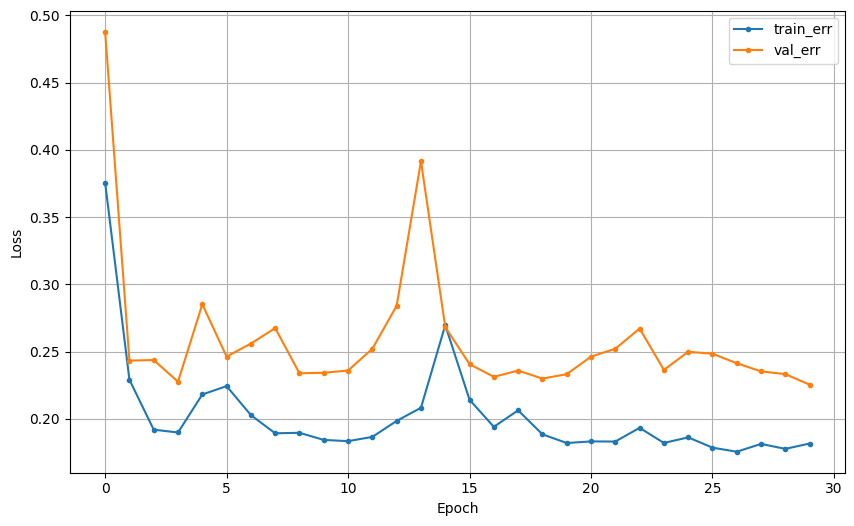

In [ ]:
# 학습곡선
dl_history_plot(static_hist)

In [ ]:
# 예측 및 평가
y_pred = static_model.predict(x_test_scaled).argmax(axis=1)

print("\n===== 정적 활동 분류 성능 =====")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(
    y_test, y_pred,
    target_names=['LAYING', 'SITTING', 'STANDING'],
    zero_division=0
))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== 정적 활동 분류 성능 =====
[[223   0   0]
 [  0 193  13]
 [  0  28 190]]

              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       223
     SITTING       0.87      0.94      0.90       206
    STANDING       0.94      0.87      0.90       218

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



#### 2) 단계2-2 : 동적 동작 세부 분류

* Walking, Walking Upstairs, Walking Downstairs 를 분류하는 모델을 생성

In [ ]:
data01_train['Activity'].value_counts()

,count
Activity,
LAYING,1115
STANDING,1087
SITTING,1032
WALKING,998
WALKING_UPSTAIRS,858
WALKING_DOWNSTAIRS,791


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. 원본 데이터 로드
data01_train = pd.read_csv('data01_train.csv')
data01_train.drop('subject', axis=1, inplace=True)

# 2. 정적 활동만 필터링
static_activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']
static_mask = data01_train['Activity'].isin(static_activities)

static_data = data01_train[static_mask].copy()

print(f"전체 데이터: {len(data01_train)}")
print(f"정적 데이터: {len(static_data)}")
print(f"정적 활동 분포:\n{static_data['Activity'].value_counts()}")

# 3. x, y 분할
select_features = ['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
                   'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
                   'tGravityAcc-max()-X', 'angle(X,gravityMean)',
                   'tBodyAcc-max()-X', 'tGravityAcc-max()-Y',
                   'angle(Y,gravityMean)', 'tGravityAcc-mean()-X']

x = static_data[select_features]
y_act = static_data['Activity']

# 4. 라벨 인코딩
activity_mapping = {
    'WALKING' : 0,
    'WALKING_UPSTAIRS' : 1,
    'WALKING_DOWNSTAIRS' : 2
}

y_act_encoded = y_act.map(activity_mapping)

print(f"\n인코딩 후 분포:\n{y_act_encoded.value_counts()}")

# 5. Train/Test 분할
x_train, x_test, y_train, y_test = train_test_split(
    x, y_act_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_act_encoded  # 클래스 비율 유지
)

print(f"\nTrain: {x_train.shape}, Test: {x_test.shape}")
print(f"Train 라벨 분포:\n{y_train.value_counts()}")
print(f"Test 라벨 분포:\n{y_test.value_counts()}")

# 6. 스케일링
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 7. 모델 설계
clear_session()
nfeatures = x_train_scaled.shape[1]

dynamic_model = Sequential([
    Input(shape=(nfeatures,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

dynamic_model.summary()

# 8. 컴파일 및 학습
dynamic_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dynamic_hist = dynamic_model.fit(
    x_train_scaled,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
).history

전체 데이터: 5881
정적 데이터: 2647
정적 활동 분포:
Activity
WALKING               998
WALKING_UPSTAIRS      858
WALKING_DOWNSTAIRS    791
Name: count, dtype: int64

인코딩 후 분포:
Activity
0    998
1    858
2    791
Name: count, dtype: int64

Train: (2117, 10), Test: (530, 10)
Train 라벨 분포:
Activity
0    798
1    686
2    633
Name: count, dtype: int64
Test 라벨 분포:
Activity
0    200
1    172
2    158
Name: count, dtype: int64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,475 (13.57 KB)

 Trainable params: 3,475 (13.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4948 - loss: 1.0132 - val_accuracy: 0.4953 - val_loss: 0.9400
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5945 - loss: 0.8733 - val_accuracy: 0.7594 - val_loss: 0.6352
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7201 - loss: 0.6695 - val_accuracy: 0.7972 - val_loss: 0.5484
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7632 - loss: 0.5705 - val_accuracy: 0.8160 - val_loss: 0.5236
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7676 - loss: 0.5584 - val_accuracy: 0.7972 - val_loss: 0.5448
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7663 - loss: 0.5575 - val_accuracy: 0.7925 - val_loss: 0.4897
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7898 - loss: 0.4978 - val_accuracy: 0.8042 - val_loss: 0.4541
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7812 - loss: 0.5002 - val_accuracy: 0.7571 - val_loss:

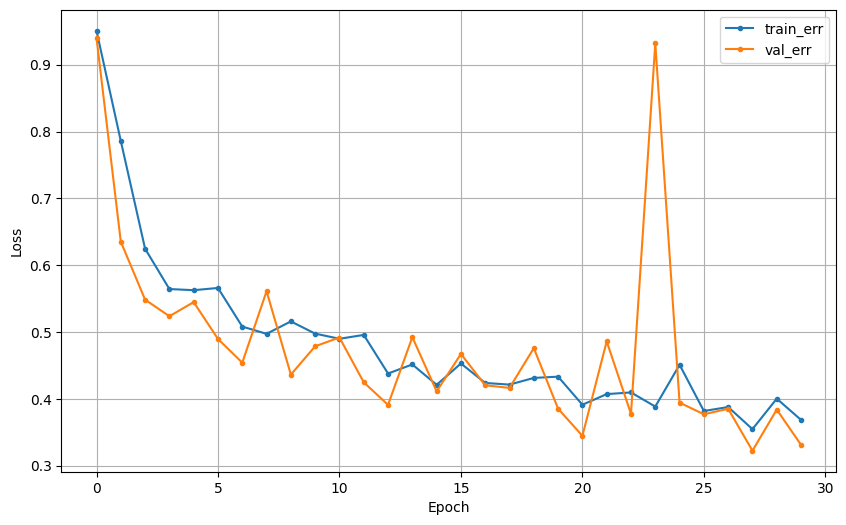

In [ ]:
dl_history_plot(dynamic_hist)

In [ ]:
# 예측 및 평가
y_pred = dynamic_model.predict(x_test_scaled).argmax(axis=1)

print("\n===== 정적 활동 분류 성능 =====")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(
    y_test, y_pred,
    target_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'],
    zero_division=0
))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== 정적 활동 분류 성능 =====
[[177  14   9]
 [ 16 145  11]
 [ 12   8 138]]

                    precision    recall  f1-score   support

           WALKING       0.86      0.89      0.87       200
  WALKING_UPSTAIRS       0.87      0.84      0.86       172
WALKING_DOWNSTAIRS       0.87      0.87      0.87       158

          accuracy                           0.87       530
         macro avg       0.87      0.87      0.87       530
      weighted avg       0.87      0.87      0.87       530



#### 1) 함수 만들기

In [ ]:
#(tip) 함수 만들기
# 1. 전처리
# 1-1. 스케일링
# 1-2. 입력값 만들기
#-------------------
# 2. 예측하기
# 2-1. 단계1을 모델로 0,1 구분
# 2-2. 단계 1의 결과로 데이터 나누기
# 2-3. 단계2 모델로 예측
# 2-4. 예측 결과 원래 값으로 변환
# 2-5. 하나로 합쳐보기
#-------------------
# 3. 최종 성능평가 하기

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.backend import clear_session

# ============================================
# 1. 데이터 준비 및 전처리
# ============================================

# 데이터 로드
data01_train = pd.read_csv('data01_train.csv')
data01_test = pd.read_csv('data01_test.csv')

# subject 제거
data01_train.drop('subject', axis=1, inplace=True, errors='ignore')
data01_test.drop('subject', axis=1, inplace=True, errors='ignore')

# 사용할 특성
select_features = ['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
                   'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
                   'tGravityAcc-max()-X', 'angle(X,gravityMean)',
                   'tBodyAcc-max()-X', 'tGravityAcc-max()-Y',
                   'angle(Y,gravityMean)', 'tGravityAcc-mean()-X']

# ============================================
# 2. 전체 데이터 스케일링 (통일된 스케일러)
# ============================================

# 전체 데이터로 스케일러 fit
x_train_all = data01_train[select_features]
x_test_all = data01_test[select_features]

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_all)
x_test_scaled = scaler.transform(x_test_all)

print("=" * 60)
print("데이터 준비 완료")
print("=" * 60)
print(f"Train 데이터: {x_train_scaled.shape}")
print(f"Test 데이터: {x_test_scaled.shape}")

# ============================================
# 3. 1단계 모델: 정적(0) vs 동적(1) 분류
# ============================================

print("\n" + "=" * 60)
print("1단계 모델: 정적/동적 분류 학습")
print("=" * 60)

# is_dynamic 라벨 생성
static_activities = ['LAYING', 'SITTING', 'STANDING']
data01_train['is_dynamic'] = data01_train['Activity'].apply(
    lambda x: 0 if x in static_activities else 1
)
data01_test['is_dynamic'] = data01_test['Activity'].apply(
    lambda x: 0 if x in static_activities else 1
)

y_train_binary = data01_train['is_dynamic'].values
y_test_binary = data01_test['is_dynamic'].values

print(f"정적(0): {(y_train_binary == 0).sum()}개")
print(f"동적(1): {(y_train_binary == 1).sum()}개")

# 클래스 가중치 계산
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_binary),
    y=y_train_binary
)
class_weight_dict = dict(enumerate(class_weights))

# 1단계 모델 생성
clear_session()
dyna_model = Sequential([
    Input(shape=(len(select_features),)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dyna_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 학습
dyna_hist = dyna_model.fit(
    x_train_scaled,
    y_train_binary,
    epochs=50,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# 1단계 평가
y_pred_binary = (dyna_model.predict(x_test_scaled, verbose=0) > 0.5).astype(int).flatten()
print("\n1단계 모델 성능:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['정적', '동적']))

# ============================================
# 4. 2단계 모델 (정적): LAYING, SITTING, STANDING
# ============================================

print("\n" + "=" * 60)
print("2단계 모델 (정적): 3개 활동 분류 학습")
print("=" * 60)

# 정적 데이터만 필터링
static_mask_train = data01_train['Activity'].isin(static_activities)
static_data_train = data01_train[static_mask_train]

x_train_static_indices = static_mask_train[static_mask_train].index
x_train_static = x_train_scaled[static_mask_train]
y_train_static = static_data_train['Activity']

# 라벨 인코딩
static_mapping = {'LAYING': 0, 'SITTING': 1, 'STANDING': 2}
y_train_static_encoded = y_train_static.map(static_mapping).values

print(f"정적 활동 분포:\n{pd.Series(y_train_static_encoded).value_counts()}")

# 정적 모델 생성
clear_session()
static_model = Sequential([
    Input(shape=(len(select_features),)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

static_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습
static_hist = static_model.fit(
    x_train_static,
    y_train_static_encoded,
    epochs=50,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

print("정적 모델 학습 완료")

# ============================================
# 5. 2단계 모델 (동적): WALKING, WALKING_DOWNSTAIRS, WALKING_UPSTAIRS
# ============================================

print("\n" + "=" * 60)
print("2단계 모델 (동적): 3개 활동 분류 학습")
print("=" * 60)

# 동적 데이터만 필터링
dynamic_activities = ['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
dynamic_mask_train = data01_train['Activity'].isin(dynamic_activities)
dynamic_data_train = data01_train[dynamic_mask_train]

x_train_dynamic = x_train_scaled[dynamic_mask_train]
y_train_dynamic = dynamic_data_train['Activity']

# 라벨 인코딩
dynamic_mapping = {'WALKING': 0, 'WALKING_DOWNSTAIRS': 1, 'WALKING_UPSTAIRS': 2}
y_train_dynamic_encoded = y_train_dynamic.map(dynamic_mapping).values

print(f"동적 활동 분포:\n{pd.Series(y_train_dynamic_encoded).value_counts()}")

# 동적 모델 생성
clear_session()
dynamic_model = Sequential([
    Input(shape=(len(select_features),)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

dynamic_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습
dynamic_hist = dynamic_model.fit(
    x_train_dynamic,
    y_train_dynamic_encoded,
    epochs=50,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

print("동적 모델 학습 완료")

# ============================================
# 6. 2단계 예측 함수
# ============================================

def predict_activity_hierarchical(data, scaler, dyna_model, static_model, dynamic_model, select_features):
    """
    2단계 계층적 예측 함수

    Parameters:
    - data: 원본 데이터 (DataFrame)
    - scaler: 통일된 스케일러
    - dyna_model: 정적/동적 분류 모델
    - static_model: 정적 활동 분류 모델
    - dynamic_model: 동적 활동 분류 모델
    - select_features: 사용할 특성 리스트

    Returns:
    - 예측된 Activity 라벨 (array)
    """

    # 1. 전처리 및 스케일링
    x_raw = data[select_features]
    x_scaled = scaler.transform(x_raw)

    print(f"\n입력 데이터: {x_scaled.shape}")

    # 2. 1단계: 정적(0) vs 동적(1) 분류
    stage1_pred_prob = dyna_model.predict(x_scaled, verbose=0)
    stage1_pred = (stage1_pred_prob > 0.5).astype(int).flatten()

    print(f"1단계 예측 - 정적: {(stage1_pred == 0).sum()}개, 동적: {(stage1_pred == 1).sum()}개")

    # 3. 데이터 나누기
    static_indices = np.where(stage1_pred == 0)[0]
    dynamic_indices = np.where(stage1_pred == 1)[0]

    # 최종 결과 저장용
    final_predictions = np.empty(len(x_scaled), dtype=object)

    # 4. 정적 데이터 예측
    if len(static_indices) > 0:
        x_static = x_scaled[static_indices]
        static_pred = static_model.predict(x_static, verbose=0).argmax(axis=1)

        # 원래 라벨로 변환
        static_mapping_reverse = {0: 'LAYING', 1: 'SITTING', 2: 'STANDING'}
        static_labels = np.array([static_mapping_reverse[p] for p in static_pred])

        final_predictions[static_indices] = static_labels
        print(f"정적 활동 예측 완료: {len(static_indices)}개")

    # 5. 동적 데이터 예측
    if len(dynamic_indices) > 0:
        x_dynamic = x_scaled[dynamic_indices]
        dynamic_pred = dynamic_model.predict(x_dynamic, verbose=0).argmax(axis=1)

        # 원래 라벨로 변환
        dynamic_mapping_reverse = {0: 'WALKING', 1: 'WALKING_DOWNSTAIRS', 2: 'WALKING_UPSTAIRS'}
        dynamic_labels = np.array([dynamic_mapping_reverse[p] for p in dynamic_pred])

        final_predictions[dynamic_indices] = dynamic_labels
        print(f"동적 활동 예측 완료: {len(dynamic_indices)}개")

    return final_predictions

# ============================================
# 7. 최종 성능 평가
# ============================================

def evaluate_hierarchical_model(y_true, y_pred):
    """
    계층적 모델 성능 평가
    """
    print("\n" + "=" * 60)
    print("최종 성능 평가")
    print("=" * 60)

    # 전체 정확도
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n전체 Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # 정적/동적 별 성능
    static_activities = ['LAYING', 'SITTING', 'STANDING']

    static_mask = pd.Series(y_true).isin(static_activities)
    if static_mask.sum() > 0:
        static_acc = accuracy_score(
            pd.Series(y_true)[static_mask],
            pd.Series(y_pred)[static_mask]
        )
        print(f"정적 활동 정확도: {static_acc:.4f}")

    dynamic_mask = ~static_mask
    if dynamic_mask.sum() > 0:
        dynamic_acc = accuracy_score(
            pd.Series(y_true)[dynamic_mask],
            pd.Series(y_pred)[dynamic_mask]
        )
        print(f"동적 활동 정확도: {dynamic_acc:.4f}")

    return accuracy

# ============================================
# 8. 실행
# ============================================

print("\n" + "=" * 60)
print("2단계 계층적 예측 시작")
print("=" * 60)

# Test 데이터로 예측
y_pred_hierarchical = predict_activity_hierarchical(
    data=data01_test,
    scaler=scaler,
    dyna_model=dyna_model,
    static_model=static_model,
    dynamic_model=dynamic_model,
    select_features=select_features
)

# 성능 평가
y_true = data01_test['Activity'].values
final_accuracy = evaluate_hierarchical_model(y_true, y_pred_hierarchical)

데이터 준비 완료
Train 데이터: (5881, 10)
Test 데이터: (1471, 10)

1단계 모델: 정적/동적 분류 학습
정적(0): 3234개
동적(1): 2647개
Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9480 - loss: 0.1458 - val_accuracy: 0.4427 - val_loss: 0.9487
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9944 - loss: 0.0141 - val_accuracy: 0.6219 - val_loss: 0.8752
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9967 - loss: 0.0099 - val_accuracy: 0.9907 - val_loss: 0.0542
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9980 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9983 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 2.2527e-04
